In [ ]:
%pip install -r requirements.txt

In [2]:
# tools
from langchain_community.tools import ArxivQueryRun
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.utilities import WikipediaAPIWrapper
 

In [3]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description="query arxiv papers in detail.")

In [5]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [6]:
api_wrapper_wikipedia=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia,description="Search wikipedia for required information.")

In [7]:
wiki.name

'wikipedia'

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [9]:
# TAVILY API KEY HELPS TO SEARCH THE INTERNET. IT IS SPECIALLY BUILT FOR RAGS AND LLMS

In [10]:
# tavily search tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily=TavilySearchResults()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19036\2547720822.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


In [11]:
tavily.invoke("what is the current time in delhi?")

[{'title': 'Current time Delhi, India. What time is it in Delhi, India',
  'url': 'https://worldinfotravel.com/country-india-city-delhi-time/',
  'content': 'WorldInfoTravel\n\n# Current time in Delhi city, IndiaNational flag of India\n\nNational flag of India\n\nThe current time now in Delhi is 16:18, Thursday, 29 January 2026, week 05\n\n## Clock online — Delhi, India\n\nThe exact time is now in your city Delhi, India National flag of India\n\nNational flag of India\n\nNow Indian Standard Time (IST), offset UTC Asia/Kolkata +05:30,  \nIndian Standard Time (IST) standard time zone\n  \nTime on your computer: Loading.... The exact time of WorldInfoTravel: is Loading.... The offset is ± Loading... ms.\n\n## The sun comes up\n\n## Summer and winter time\n\n## Information about the city Delhi, India\n\nCity Delhi, the capital of country India\n\nCity Delhi minimap\n\nDelhi is the capital of India. Delhi is located on the continent of Asia. [...] |  |  |\n --- |\n| Continent | Asia |\n| Co

In [12]:
# combime all these tools in a list
tools=[arxiv,wiki,tavily]

In [20]:
# initialize the llm model
from langchain_groq import ChatGroq 

llm=ChatGroq(model="qwen/qwen3-32b")

In [21]:
llm.invoke("what is the 1 line difference between ai and ml")

AIMessage(content='<think>\nOkay, the user is asking for a one-line difference between AI and ML. Let me start by recalling what each term means. AI is the broader concept of machines performing tasks that require human intelligence, like problem-solving or decision-making. Machine learning is a subset of AI that focuses on algorithms learning from data. So the key difference is that AI is the general idea, and ML is a specific method within AI.\n\nWait, how to phrase it in one line? Maybe start with "AI is the overarching field..." and then ML as a subset. Need to make sure it\'s concise. Let me check if there\'s any common phrasing for this. Oh right, sometimes people say ML is a subset of AI. So the line could be: "Artificial Intelligence (AI) is the overarching field of machines performing tasks requiring human intelligence, while Machine Learning (ML) is a subset focused on algorithms improving through data-driven learning."\n\nDoes that capture the difference? AI includes other m

In [22]:
# combine these tools with lllm
llm_with_tools=llm.bind_tools(tools=tools)

In [23]:
llm_with_tools.invoke("what is the recent news on ai?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news on AI. I need to figure out which tool to use here. The available tools are arxiv, wikipedia, and tavily_search_results_json. \n\nArxiv is for academic papers, so maybe not the best choice for news. Wikipedia might have some information, but it\'s more of an encyclopedia and might not have the latest updates. Tavily_search_results_json is described as a search engine optimized for current events, so that sounds like the right fit here.\n\nI should use tavily_search_results_json with a query like "recent news on AI" or "latest AI developments". Let me make sure the query is specific enough. The user wants recent news, so maybe include a time frame? But the tool\'s description says it\'s for current events, so maybe just "recent AI news" as the query. \n\nI\'ll go with "recent AI news" as the query parameter. Let me structure the tool call correctly. The function name is tavily_search_

In [24]:
# now lets create the complete workflow using langgraph
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage #can be either human or ai message
from typing import Annotated #labelling
from langgraph.graph.message import add_messages # reducers langgraph 

In [25]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages] # add_messages would be a function which would append messanges in the messages variable instead of overwriting it
    

In [27]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [33]:
# node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# build the graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

In [34]:
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
# if the latest message (result) from assistant is a tool call then tool_condition would route to tools
# if the latest message (result) from assistant is not a tool call then tool_condition would route to end
builder.add_edge("tools",END)

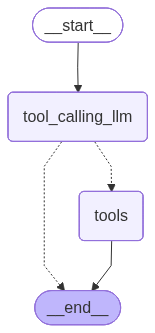

In [35]:
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
from langchain_core.messages import HumanMessage

messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (b8pemr11y)
 Call ID: b8pemr11y
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [39]:
# lets build another graph where after a request goes to tools then it goes to llm instead of going to END

# build the graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

In [40]:
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")

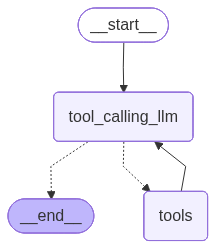

In [42]:
graph2=builder.compile()
display(Image(graph2.get_graph().draw_mermaid_png()))

In [44]:
from langchain_core.messages import HumanMessage

messages=graph2.invoke({"messages":HumanMessage(content="himy name is vinay and i want to get recent news on ai")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

himy name is vinay and i want to get recent news on ai
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (ew6kx7r6y)
 Call ID: ew6kx7r6y
  Args:
    query: recent news on AI
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business ...", "url": "https://www.artificialintelligence-news.com/", "content": "# How to Calculate Business Value and Cost for Generative AI Use Cases\n\n#### Applications\n\n### Thailand becomes one of the first in Asia to get the Sora app\n\nEntertainment & Media\n\nOctober 30, 2025\n\n### Malaysia launches Ryt Bank, its first AI-powered bank\n\nFinance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly 29, 2025\n\n####